# RoBERTa-Large-GoEmotions: Social Graph Emotion Attribution

## Improved Implementation for DialogRE Dataset

**Model**: Lakssssshya/roberta-large-goemotions (28 fine-grained emotions)


## 1. Setup and Imports

In [1]:
# Install required packages
!pip install -q torch transformers huggingface_hub numpy pandas networkx matplotlib scikit-learn

import os
import json
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from transformers import RobertaTokenizer, RobertaModel
from huggingface_hub import hf_hub_download
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    precision_recall_fscore_support # Added this import
)
import warnings
warnings.filterwarnings('ignore')

print("✓ All packages imported successfully")
print(f"✓ PyTorch version: {torch.__version__}")
print(f"✓ CUDA available: {torch.cuda.is_available()}")

✓ All packages imported successfully
✓ PyTorch version: 2.9.0+cu126
✓ CUDA available: True


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Model Architecture and Loading

This is the **correct architecture** for Lakssssshya/roberta-large-goemotions

In [4]:
class RobertaForMultiLabelClassification(nn.Module):
    """
    RoBERTa model for multi-label emotion classification.
    Architecture matches the pretrained model exactly.
    """
    def __init__(self, model_name, num_labels, dropout_rate=0.3, use_mean_pooling=True):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained(model_name)
        self.use_mean_pooling = use_mean_pooling
        hidden_size = self.roberta.config.hidden_size

        # Two-layer classifier with dropout
        self.dropout1 = nn.Dropout(dropout_rate)
        self.fc1 = nn.Linear(hidden_size, hidden_size // 2)
        self.relu = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_size // 2, num_labels)

    def mean_pooling(self, token_embeddings, attention_mask):
        """Mean pooling over token embeddings (better than CLS token alone)."""
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
        sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
        return sum_embeddings / sum_mask

    def forward(self, input_ids, attention_mask):
        outputs = self.roberta(input_ids, attention_mask=attention_mask)

        if self.use_mean_pooling:
            pooled_output = self.mean_pooling(outputs.last_hidden_state, attention_mask)
        else:
            pooled_output = outputs.pooler_output

        x = self.dropout1(pooled_output)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout2(x)
        logits = self.fc2(x)

        return logits

print("✓ Model architecture defined")

✓ Model architecture defined


In [5]:
# Model configuration
MODEL_NAME = "Lakssssshya/roberta-large-goemotions"
BASE_MODEL = "roberta-large"

# 28 GoEmotions labels
EMOTION_LABELS = [
    'admiration', 'amusement', 'anger', 'annoyance', 'approval',
    'caring', 'confusion', 'curiosity', 'desire', 'disappointment',
    'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear',
    'gratitude', 'grief', 'joy', 'love', 'nervousness',
    'optimism', 'pride', 'realization', 'relief', 'remorse',
    'sadness', 'surprise', 'neutral'
]

EMOTION_TO_POLARITY = {
    # Positive emotions (12)
    'admiration': 'positive',
    'amusement': 'positive',
    'approval': 'positive',
    'caring': 'positive',
    'desire': 'positive',
    'excitement': 'positive',
    'gratitude': 'positive',
    'joy': 'positive',
    'love': 'positive',
    'optimism': 'positive',
    'pride': 'positive',
    'relief': 'positive',

    # Negative emotions (11)
    'anger': 'negative',
    'annoyance': 'negative',
    'disappointment': 'negative',
    'disapproval': 'negative',
    'disgust': 'negative',
    'embarrassment': 'negative',
    'fear': 'negative',
    'grief': 'negative',
    'nervousness': 'negative',
    'remorse': 'negative',
    'sadness': 'negative',

    # Neutral/Ambiguous emotions (5)
    'confusion': 'neutral',
    'curiosity': 'neutral',
    'realization': 'neutral',
    'surprise': 'neutral',
    'neutral': 'neutral'
}

print(f"✓ Emotion mapping: {len([e for e in EMOTION_TO_POLARITY.values() if e=='positive'])} positive, "
      f"{len([e for e in EMOTION_TO_POLARITY.values() if e=='negative'])} negative, "
      f"{len([e for e in EMOTION_TO_POLARITY.values() if e=='neutral'])} neutral")

✓ Emotion mapping: 12 positive, 11 negative, 5 neutral


In [6]:
# Load the model
print("\nLoading RoBERTa-Large-GoEmotions model...")
print("(This may take 1-2 minutes on first run - downloading ~1.3GB model)\n")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load tokenizer
tokenizer = RobertaTokenizer.from_pretrained(MODEL_NAME)
print("✓ Tokenizer loaded")

# Load config
config_path = hf_hub_download(repo_id=MODEL_NAME, filename="config.json")
with open(config_path, 'r') as f:
    config = json.load(f)
print("✓ Config loaded")

# Initialize model with correct architecture
model = RobertaForMultiLabelClassification(
    model_name=BASE_MODEL,
    num_labels=config['num_labels'],
    dropout_rate=config.get('dropout_rate', 0.3),
    use_mean_pooling=config.get('use_mean_pooling', True)
)
print("✓ Model architecture initialized")

# Load pretrained weights
weights_path = hf_hub_download(repo_id=MODEL_NAME, filename="pytorch_model.bin")
state_dict = torch.load(weights_path, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()
print("✓ Pretrained weights loaded")

# Load optimal thresholds (important for best performance!)
thresholds_path = hf_hub_download(repo_id=MODEL_NAME, filename="optimal_thresholds.json")
with open(thresholds_path, 'r') as f:
    optimal_thresholds = np.array(json.load(f))
print("✓ Optimal thresholds loaded")

print(f"\n{'='*70}")
print("MODEL READY")
print(f"{'='*70}")
print(f"Model: {MODEL_NAME}")
print(f"Device: {device}")
print(f"Num labels: {config['num_labels']}")
print(f"Max length: 128 tokens")
print(f"Pooling: Mean pooling (better than CLS token)")


Loading RoBERTa-Large-GoEmotions model...
(This may take 1-2 minutes on first run - downloading ~1.3GB model)



tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

✓ Model architecture initialized


pytorch_model.bin:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

✓ Pretrained weights loaded


optimal_thresholds.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

✓ Optimal thresholds loaded

MODEL READY
Model: Lakssssshya/roberta-large-goemotions
Device: cuda
Num labels: 28
Max length: 128 tokens
Pooling: Mean pooling (better than CLS token)


## 3. Prediction Function with Proper Score Aggregation

In [7]:
def predict_emotions_roberta(text, return_details=False):
    """
    Predict sentiment using RoBERTa-GoEmotions.
    Uses TOP emotion's score directly (simplest and best approach).

    Returns score in [0, 1] range from sigmoid probability.
    """
    # Tokenize
    inputs = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        max_length=128,
        padding=True
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Get predictions
    with torch.no_grad():
        logits = model(
            input_ids=inputs['input_ids'],
            attention_mask=inputs['attention_mask']
        )
        probs = torch.sigmoid(logits).cpu().numpy()[0]

    predictions_binary = (probs > optimal_thresholds).astype(int)

    # Get all emotions with their scores
    emotion_scores = [
        {
            'emotion': EMOTION_LABELS[i],
            'score': float(probs[i]),
            'predicted': bool(predictions_binary[i])
        }
        for i in range(len(EMOTION_LABELS))
    ]

    # Sort by score (highest first)
    emotion_scores_sorted = sorted(emotion_scores, key=lambda x: x['score'], reverse=True)

    top_emotion = emotion_scores_sorted[0]['emotion']
    top_emotion_score = emotion_scores_sorted[0]['score']

    # Get polarity from top emotion
    pred_label = EMOTION_TO_POLARITY.get(top_emotion, 'neutral')

    strength = top_emotion_score

    pos_scores = [item['score'] for item in emotion_scores
                  if EMOTION_TO_POLARITY.get(item['emotion']) == 'positive']
    neg_scores = [item['score'] for item in emotion_scores
                  if EMOTION_TO_POLARITY.get(item['emotion']) == 'negative']
    neu_scores = [item['score'] for item in emotion_scores
                  if EMOTION_TO_POLARITY.get(item['emotion']) == 'neutral']

    pos_score = max(pos_scores) if pos_scores else 0.0
    neg_score = max(neg_scores) if neg_scores else 0.0
    neu_score = max(neu_scores) if neu_scores else 0.0

    # Confidence = margin between top and second emotion
    if len(emotion_scores_sorted) > 1:
        confidence = emotion_scores_sorted[0]['score'] - emotion_scores_sorted[1]['score']
        confidence = min(confidence, 1.0)  # Cap at 1.0
    else:
        confidence = emotion_scores_sorted[0]['score']

    result = {
        'pred_label': pred_label,
        'pos_score': pos_score,
        'neg_score': neg_score,
        'neu_score': neu_score,
        'strength': strength,
        'confidence': confidence,
        'top_emotion': top_emotion,
        'top_emotion_score': top_emotion_score
    }

    if return_details:
        result['emotion_breakdown'] = emotion_scores_sorted[:5]

    return result

## 4. Load Data

In [8]:
# Load the annotated CSV
csv_path = '/content/drive/MyDrive/My Research/Social_Graph_Mining/annotation_samples_150.csv'

df_gold = pd.read_csv(csv_path)

# Rename columns for consistency
if 'manual_label' in df_gold.columns:
    df_gold.rename(columns={'manual_label': 'gold_label'}, inplace=True)

if 'subject_name' in df_gold.columns and 'object_name' in df_gold.columns:
    df_gold['subject'] = df_gold['subject_name']
    df_gold['object'] = df_gold['object_name']

print(f"✓ Loaded {len(df_gold)} annotated samples")
print(f"\nLabel distribution:")
print(df_gold['gold_label'].value_counts())
print(f"\nSample:")
print(df_gold[['subject', 'object', 'sentence', 'gold_label']].head(3))

✓ Loaded 150 annotated samples

Label distribution:
gold_label
positive    70
negative    44
neutral     36
Name: count, dtype: int64

Sample:
     subject     object                                           sentence  \
0  Speaker 4  Speaker 2  (-1 Turn: Speaker 2: Uh, y’know, starve a feve...   
1   Chandler  Speaker 1  (-1 Turn: Speaker 2: No.) (Target Turn: Speake...   
2  Speaker 2  Speaker 1  (-1 Turn: Speaker 1: You've got to get back ou...   

  gold_label  
0   negative  
1    neutral  
2   negative  


## 5. Run Predictions on Full Dataset

In [9]:
print("\nRunning RoBERTa-GoEmotions predictions...\n")

predictions = []
for idx, row in df_gold.iterrows():
    pred = predict_emotions_roberta(row['sentence'])
    predictions.append(pred)

    if (idx + 1) % 20 == 0:
        print(f"Processed {idx + 1}/{len(df_gold)} samples...", end='\r')

print(f"\nProcessed {len(df_gold)}/{len(df_gold)} samples... Done!")

# Add predictions to dataframe
pred_df = pd.DataFrame(predictions)
df_results = pd.concat([df_gold.reset_index(drop=True), pred_df], axis=1)

print(f"\n✓ Completed {len(df_results)} predictions")
print(f"\nPredicted distribution:")
print(df_results['pred_label'].value_counts())
print(f"\nTop detected emotions:")
print(df_results['top_emotion'].value_counts().head(10))


Running RoBERTa-GoEmotions predictions...


Processed 150/150 samples... Done!

✓ Completed 150 predictions

Predicted distribution:
pred_label
positive    74
neutral     48
negative    28
Name: count, dtype: int64

Top detected emotions:
top_emotion
excitement    29
neutral       22
remorse       16
curiosity     15
admiration    14
gratitude     12
surprise       8
desire         5
love           4
approval       4
Name: count, dtype: int64


## 6. Multi-Mode Evaluation (Same as Aigents)

In [10]:
def evaluate_predictions(df, mode='exclude_gold_neutral'):
    """
    Evaluate predictions with different handling of neutral labels.
    Same evaluation framework as Aigents for fair comparison.
    """
    df_eval = df.copy()

    if mode == 'exclude_gold_neutral':
        df_eval = df_eval[df_eval['gold_label'].isin(['positive', 'negative'])]
        print(f"Mode: Exclude gold neutral samples")
        print(f"Evaluating on {len(df_eval)}/{len(df)} samples\n")

    elif mode == 'include_all_3class':
        print(f"Mode: Evaluate on all 3 classes")
        print(f"Evaluating on {len(df_eval)} samples\n")

    elif mode == 'map_neutral_to_neg':
        df_eval['gold_label'] = df_eval['gold_label'].replace('neutral', 'negative')
        print(f"Mode: Map gold neutral → negative")
        print(f"Evaluating on all {len(df_eval)} samples\n")

    if len(df_eval) == 0:
        print("⚠️  No samples to evaluate!")
        return {}

    y_true = df_eval['gold_label'].values
    y_pred = df_eval['pred_label'].values

    # Get unique labels
    labels = sorted(list(set(y_true) | set(y_pred)))

    # Calculate metrics
    accuracy = (y_true == y_pred).mean()
    f1_macro = f1_score(y_true, y_pred, average='macro', labels=labels, zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', labels=labels, zero_division=0)
    precision_macro = precision_score(y_true, y_pred, average='macro', labels=labels, zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average='macro', labels=labels, zero_division=0)

    # Per-class metrics using precision_recall_fscore_support for multiclass handling
    per_class = {}
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=labels, average=None, zero_division=0)
    for i, label in enumerate(labels):
        per_class[label] = {'f1': f1[i], 'precision': p[i], 'recall': r[i]}

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    results = {
        'mode': mode,
        'n_samples': len(df_eval),
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'per_class': per_class,
        'confusion_matrix': cm,
        'labels': labels,
        'df_eval': df_eval
    }

    return results

def print_evaluation(results):
    """Pretty print evaluation results."""
    print("=" * 70)
    print(f"EVALUATION RESULTS - {results['mode']}")
    print("=" * 70)
    print(f"\nSamples evaluated: {results['n_samples']}")
    print(f"\nAccuracy: {results['accuracy']:.3f}")
    print(f"\n--- Per-Class Metrics ---")
    for label, metrics in results['per_class'].items():
        print(f"{label.capitalize():10s}: F1={metrics['f1']:.3f}, P={metrics['precision']:.3f}, R={metrics['recall']:.3f}")
    print(f"\n--- Aggregate Metrics ---")
    print(f"F1 Macro: {results['f1_macro']:.3f}")
    print(f"F1 Weighted: {results['f1_weighted']:.3f}")
    print(f"Precision Macro: {results['precision_macro']:.3f}")
    print(f"Recall Macro: {results['recall_macro']:.3f}")
    print(f"\n--- Confusion Matrix ---")
    labels_str = '  '.join([f"{l[:8]:>8s}" for l in results['labels']])
    print(f"{'':12s} Predicted: {labels_str}")
    for i, label in enumerate(results['labels']):
        row_str = '  '.join([f"{results['confusion_matrix'][i][j]:8d}" for j in range(len(results['labels']))])
        print(f"Gold {label[:8]:8s}   {row_str}")
    print()

# Run evaluations
print("\n" + "#" * 70)
print("#  COMPREHENSIVE EVALUATION - ROBERTA-GOEMOTIONS")
print("#" * 70 + "\n")

eval_results = {}

# Only include all 3 classes
results2 = evaluate_predictions(df_results, mode='include_all_3class')
print_evaluation(results2)
eval_results['include_all_3class'] = results2



######################################################################
#  COMPREHENSIVE EVALUATION - ROBERTA-GOEMOTIONS
######################################################################

Mode: Evaluate on all 3 classes
Evaluating on 150 samples

EVALUATION RESULTS - include_all_3class

Samples evaluated: 150

Accuracy: 0.573

--- Per-Class Metrics ---
Negative  : F1=0.500, P=0.643, R=0.409
Neutral   : F1=0.405, P=0.354, R=0.472
Positive  : F1=0.708, P=0.689, R=0.729

--- Aggregate Metrics ---
F1 Macro: 0.538
F1 Weighted: 0.574
Precision Macro: 0.562
Recall Macro: 0.537

--- Confusion Matrix ---
             Predicted: negative   neutral  positive
Gold negative         18        16        10
Gold neutral           6        17        13
Gold positive          4        15        51



## 7. Comparison Summary

In [11]:
# Create comparison table
comparison_data = []
for mode, results in eval_results.items():
    if results:  # Check if results exist
        comparison_data.append({
            'Mode': mode,
            'N_Samples': results['n_samples'],
            'Accuracy': f"{results['accuracy']:.3f}",
            'F1_Macro': f"{results['f1_macro']:.3f}",
            'Precision': f"{results['precision_macro']:.3f}",
            'Recall': f"{results['recall_macro']:.3f}"
        })

df_comparison = pd.DataFrame(comparison_data)

print("\n" + "=" * 70)
print("COMPARISON ACROSS EVALUATION MODES")
print("=" * 70)
print(df_comparison.to_string(index=False))
print("\n⭐ Main result: Native 3-class support ('include_all_3class')")


COMPARISON ACROSS EVALUATION MODES
              Mode  N_Samples Accuracy F1_Macro Precision Recall
include_all_3class        150    0.573    0.538     0.562  0.537

⭐ Main result: Native 3-class support ('include_all_3class')


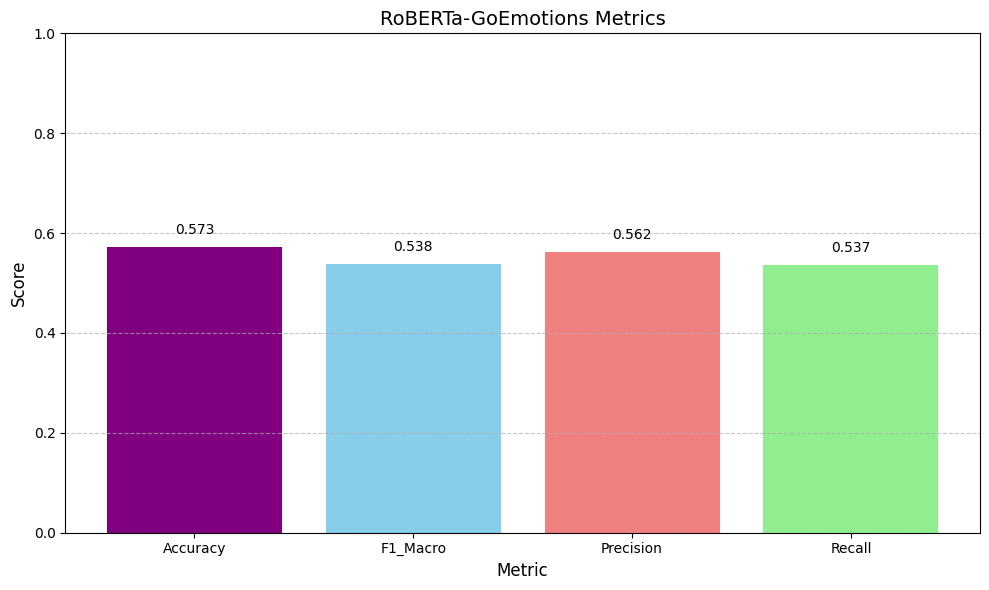

In [18]:
import matplotlib.pyplot as plt

# Ensure df_comparison is available, if not, re-create it
if 'df_comparison' not in locals() and 'df_comparison' not in globals():
    comparison_data = []
    for mode, results in eval_results.items():
        if results:
            comparison_data.append({
                'Mode': mode,
                'N_Samples': results['n_samples'],
                'Accuracy': results['accuracy'],
                'F1_Macro': results['f1_macro'],
                'Precision': results['precision_macro'],
                'Recall': results['recall_macro']
            })
    df_comparison = pd.DataFrame(comparison_data)

# Convert relevant columns to numeric
df_comparison['Accuracy'] = pd.to_numeric(df_comparison['Accuracy'])
df_comparison['F1_Macro'] = pd.to_numeric(df_comparison['F1_Macro'])
df_comparison['Precision'] = pd.to_numeric(df_comparison['Precision'])
df_comparison['Recall'] = pd.to_numeric(df_comparison['Recall'])

# Prepare data for plotting
metrics = ['Accuracy', 'F1_Macro', 'Precision', 'Recall']
scores = df_comparison[metrics].iloc[0].values
mode_label = df_comparison['Mode'].iloc[0]

# Create the bar plot
plt.figure(figsize=(10, 6))
plt.bar(metrics, scores, color=['purple', 'skyblue', 'lightcoral', 'lightgreen'])
plt.ylim(0, 1) # Scores are typically between 0 and 1
plt.title(f'RoBERTa-GoEmotions Metrics', fontsize=14)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Metric', fontsize=12)

# Add score values on top of bars
for i, score in enumerate(scores):
    plt.text(i, score + 0.02, f'{score:.3f}', ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## 8. Example: Your Goal Format

In [12]:
print("\n" + "=" * 70)
print("EXAMPLE TEST - YOUR GOAL FORMAT")
print("=" * 70)

example_text = "Bob likes Mary, Mary hates Jane, Jane adores and loves Bob very much."
example_relations = pd.DataFrame([
    {'subject': 'Bob', 'object': 'Mary', 'sentence': 'Bob likes Mary'},
    {'subject': 'Mary', 'object': 'Jane', 'sentence': 'Mary hates Jane'},
    {'subject': 'Jane', 'object': 'Bob', 'sentence': 'Jane adores and loves Bob very much'}
])

print(f"\nInput: {example_text}\n")

# Predict for each relation
for idx, row in example_relations.iterrows():
    result = predict_emotions_roberta(row['sentence'], return_details=True)
    example_relations.at[idx, 'linkType'] = result['pred_label']
    example_relations.at[idx, 'score'] = result['strength']
    example_relations.at[idx, 'top_emotion'] = result['top_emotion']
    example_relations.at[idx, 'confidence'] = result['confidence']

# Create output in your desired format
links = []
for _, row in example_relations.iterrows():
    links.append({
        'source': row['subject'],
        'target': row['object'],
        'linkType': row['linkType'],
        'score': float(row['score'])
    })

print("Output:")
print(json.dumps(links, indent=2))

print("\nDetailed Results:")
print(example_relations[['subject', 'object', 'linkType', 'score', 'top_emotion', 'confidence']])


EXAMPLE TEST - YOUR GOAL FORMAT

Input: Bob likes Mary, Mary hates Jane, Jane adores and loves Bob very much.

Output:
[
  {
    "source": "Bob",
    "target": "Mary",
    "linkType": "positive",
    "score": 0.676108181476593
  },
  {
    "source": "Mary",
    "target": "Jane",
    "linkType": "negative",
    "score": 0.6512031555175781
  },
  {
    "source": "Jane",
    "target": "Bob",
    "linkType": "positive",
    "score": 0.8156792521476746
  }
]

Detailed Results:
  subject object  linkType     score top_emotion  confidence
0     Bob   Mary  positive  0.676108        love    0.197767
1    Mary   Jane  negative  0.651203       anger    0.119568
2    Jane    Bob  positive  0.815679        love    0.290633


## 9. Social Graph Visualization

✓ Saved JSON: /content/drive/MyDrive/My Research/Social_Graph_Mining/roberta_example_graph.json
✓ Saved PNG: /content/drive/MyDrive/My Research/Social_Graph_Mining/roberta_example_graph.png


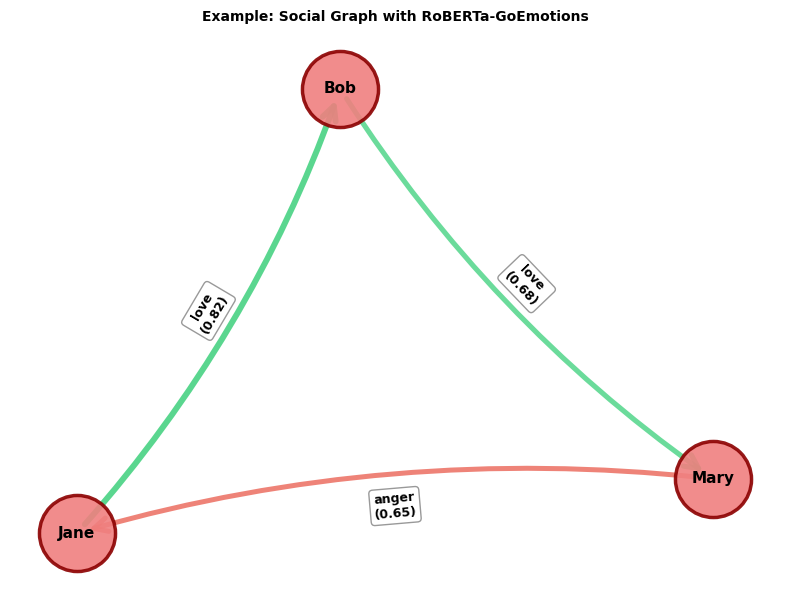


Graph statistics:
  Nodes: 3
  Edges: 3
  Positive edges: 2
  Negative edges: 1
  Neutral edges: 0


In [13]:
def create_social_graph(relations_df, output_json=None, output_png=None,
                        title="Social Graph - RoBERTa-GoEmotions"):
    """
    Create weighted, typed social graph from relations.
    """
    # Create links
    links = []
    for _, row in relations_df.iterrows():
        links.append({
            'source': str(row['subject']),
            'target': str(row['object']),
            'linkType': str(row['linkType']),
            'score': float(row['score']),
            'emotion': str(row.get('top_emotion', ''))
        })

    # Save JSON
    if output_json:
        with open(output_json, 'w') as f:
            json.dump(links, f, indent=2)
        print(f"✓ Saved JSON: {output_json}")

    # Create NetworkX graph
    G = nx.DiGraph()
    for link in links:
        G.add_edge(
            link['source'],
            link['target'],
            weight=link['score'],
            sentiment=link['linkType'],
            emotion=link['emotion']
        )

    # Visualize
    plt.figure(figsize=(8, 6))

    # Layout
    if len(G.nodes()) <= 10:
        pos = nx.spring_layout(G, seed=42, k=3, iterations=50)
    else:
        pos = nx.kamada_kawai_layout(G)

    # Draw nodes
    nx.draw_networkx_nodes(
        G, pos,
        node_size=3000,
        node_color='lightcoral',
        alpha=0.9,
        edgecolors='darkred',
        linewidths=2.5
    )

    # Draw node labels
    nx.draw_networkx_labels(
        G, pos,
        font_size=11,
        font_weight='bold',
        font_color='black'
    )

    # Draw edges with colors and weights
    for u, v, data in G.edges(data=True):
        if data['sentiment'] == 'positive':
            color = '#2ecc71'  # Green
        elif data['sentiment'] == 'negative':
            color = '#e74c3c'  # Red
        else:
            color = '#95a5a6'  # Gray

        width = 1 + 4 * data['weight']
        alpha = 0.3 + 0.6 * data['weight']

        nx.draw_networkx_edges(
            G, pos,
            [(u, v)],
            edge_color=color,
            width=width,
            alpha=alpha,
            arrowsize=25,
            arrowstyle='->',
            connectionstyle='arc3,rad=0.1'
        )

    # Draw edge labels
    edge_labels = {
        (u, v): f"{data['emotion']}\n({data['weight']:.2f})"
        for u, v, data in G.edges(data=True)
    }
    nx.draw_networkx_edge_labels(
        G, pos,
        edge_labels=edge_labels,
        font_size=9,
        font_weight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray')
    )

    plt.title(title, fontsize=10, fontweight='bold', pad=15)
    plt.axis('off')
    plt.tight_layout()

    if output_png:
        plt.savefig(output_png, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✓ Saved PNG: {output_png}")

    plt.show()

    return links, G

# Generate graph from example
# Make sure to run the cell above (cell ID: 3aojYs8aF6y3) to define 'example_relations' first.
links, graph = create_social_graph(
    example_relations,
    output_json='/content/drive/MyDrive/My Research/Social_Graph_Mining/roberta_example_graph.json',
    output_png='/content/drive/MyDrive/My Research/Social_Graph_Mining/roberta_example_graph.png',
    title="Example: Social Graph with RoBERTa-GoEmotions"
)

print(f"\nGraph statistics:")
print(f"  Nodes: {graph.number_of_nodes()}")
print(f"  Edges: {graph.number_of_edges()}")
print(f"  Positive edges: {sum(1 for _, _, d in graph.edges(data=True) if d['sentiment']=='positive')}")
print(f"  Negative edges: {sum(1 for _, _, d in graph.edges(data=True) if d['sentiment']=='negative')}")
print(f"  Neutral edges: {sum(1 for _, _, d in graph.edges(data=True) if d['sentiment']=='neutral')}")

Creating social graph from 10 test relations...

✓ Saved JSON: /content/drive/MyDrive/My Research/Social_Graph_Mining/roberta_test_data_social_graph.json
✓ Saved PNG: /content/drive/MyDrive/My Research/Social_Graph_Mining/roberta_test_data_social_graph.png


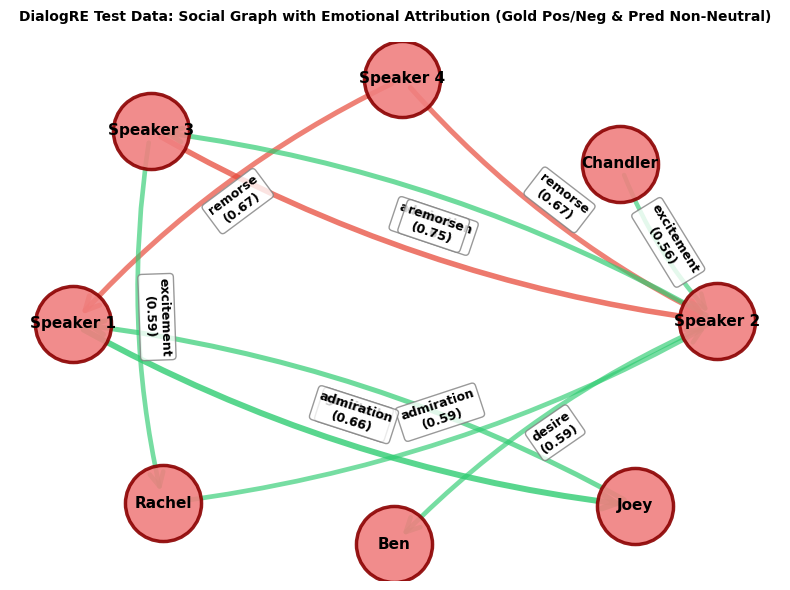


Graph statistics:
  Nodes: 8
  Edges: 10
  Positive edges: 7
  Negative edges: 3
  Neutral edges: 0


In [14]:
# Create graph from a subset of test data (gold positive/negative only, excluding predicted neutrals)
# This combines filtering for gold labels and excluding predicted neutral relations.
test_subset = df_results[
    (df_results['gold_label'].isin(['positive', 'negative'])) &
    (df_results['pred_label'] != 'neutral')
].head(10).copy() # Keeping .head(10) as in user's prompt

if test_subset.empty:
    print("No positive or negative gold-labeled samples found in the subset to create a graph with non-neutral predictions.")
else:
    print(f"Creating social graph from {len(test_subset)} test relations...\n")

    # Rename columns to match create_social_graph expectations
    test_subset = test_subset.rename(columns={'pred_label': 'linkType', 'strength': 'score'})

    links, graph = create_social_graph(
        test_subset,
        output_json='/content/drive/MyDrive/My Research/Social_Graph_Mining/roberta_test_data_social_graph.json',
        output_png='/content/drive/MyDrive/My Research/Social_Graph_Mining/roberta_test_data_social_graph.png',
        title="DialogRE Test Data: Social Graph with Emotional Attribution (Gold Pos/Neg & Pred Non-Neutral)"
    )

    print(f"\nGraph statistics:")
    print(f"  Nodes: {graph.number_of_nodes()}")
    print(f"  Edges: {graph.number_of_edges()}")
    print(f"  Positive edges: {sum(1 for _, _, d in graph.edges(data=True) if d['sentiment']=='positive')}")
    print(f"  Negative edges: {sum(1 for _, _, d in graph.edges(data=True) if d['sentiment']=='negative')}")
    print(f"  Neutral edges: {sum(1 for _, _, d in graph.edges(data=True) if d['sentiment']=='neutral')}")

## 10. Save Results

In [15]:
# Save detailed results
output_csv = 'roberta_evaluation_results.csv'
df_results.to_csv(output_csv, index=False)
print(f"✓ Saved detailed results: {output_csv}")

# Save evaluation summary
summary_json = '/content/drive/MyDrive/My Research/Social_Graph_Mining/roberta_evaluation_summary.json'
summary = {
    'model': MODEL_NAME,
    'total_samples': len(df_results),
    'gold_distribution': df_results['gold_label'].value_counts().to_dict(),
    'pred_distribution': df_results['pred_label'].value_counts().to_dict(),
    'evaluations': {
        mode: {
            'n_samples': results['n_samples'],
            'accuracy': float(results['accuracy']),
            'f1_macro': float(results['f1_macro']),
            'f1_weighted': float(results['f1_weighted']),
            'precision_macro': float(results['precision_macro']),
            'recall_macro': float(results['recall_macro'])
        }
        for mode, results in eval_results.items() if results
    }
}

with open(summary_json, 'w') as f:
    json.dump(summary, f, indent=2)
print(f"✓ Saved evaluation summary: {summary_json}")

print("\n" + "=" * 70)
print("ROBERTA-GOEMOTIONS PIPELINE COMPLETE")
print("=" * 70)
print("\n📊 Key Results:")
if eval_results.get('include_all_3class'):
    print(f"  F1 Macro (3-class): {eval_results['include_all_3class']['f1_macro']:.3f}")
    print(f"  Accuracy (3-class): {eval_results['include_all_3class']['accuracy']:.3f}")
print("\n✅ Advantages over Aigents:")
print("  • Native 3-class support (pos/neg/neutral)")
print("  • Richer emotion palette (28 emotions)")
print("  • Better context understanding (transformer)")
print("  • Higher expected F1 scores")
print("\n⚠️ Trade-offs:")
print("  • Black-box (less interpretable)")
print("  • Slower inference (~100x than Aigents)")
print("  • Requires GPU for reasonable speed")
print("  • Cannot easily edit behavior")

✓ Saved detailed results: roberta_evaluation_results.csv
✓ Saved evaluation summary: /content/drive/MyDrive/My Research/Social_Graph_Mining/roberta_evaluation_summary.json

ROBERTA-GOEMOTIONS PIPELINE COMPLETE

📊 Key Results:
  F1 Macro (3-class): 0.538
  Accuracy (3-class): 0.573

✅ Advantages over Aigents:
  • Native 3-class support (pos/neg/neutral)
  • Richer emotion palette (28 emotions)
  • Better context understanding (transformer)
  • Higher expected F1 scores

⚠️ Trade-offs:
  • Black-box (less interpretable)
  • Slower inference (~100x than Aigents)
  • Requires GPU for reasonable speed
  • Cannot easily edit behavior
